<a href="https://colab.research.google.com/gist/nmagee/e201f94f17ec68d048f8082f33b550d9/python-mysql.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python and MySQL

Database operations using Python3.

## Setup

To get started, let's add some imports:

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import mysql.connector
from mysql.connector import Error

Now set up some variables for a connection string and a cursor:

In [ ]:
DBHOST = "ds2022.cgls84scuy1e.us-east-1.rds.amazonaws.com"
DBUSER = "ds2022"
DBPASS = ""  # password on Canvas
DBNAME = "people"  # MOCK_DATA lives here

In [36]:
db = mysql.connector.connect(user=DBUSER, host=DBHOST, password=DBPASS, database=DBNAME)
cur = db.cursor()

## Basic `SELECT` Queries

Output to a List

In [37]:
# Build a simple SELECT query output into a list

def get_people():
  query = "SELECT * FROM MOCK_DATA WHERE id > 5 AND id < 20 ORDER BY last_name;"
  try:
    cur.execute(query)
    results = cur.fetchall()
    output = []
    for r in results:
      output.append(r)
    return(output)

  except mysql.connector.Error as e:
    print("MySQL Error: ", str(e))

  cur.close()

get_people()

[(12, 'Jacalin', 'Bromage', 'jbromageb@shutterfly.com', '96.66.164.103', 'AF'),
 (7, 'Katie', 'Calkin', 'kcalkin6@friendfeed.com', '1.73.123.235', 'AF'),
 (8, 'Scotti', 'Caslane', 'scaslane7@fema.gov', '156.50.68.36', 'AS'),
 (19, 'Danya', 'Ebbin', 'debbini@networksolutions.com', '42.15.118.51', 'NA'),
 (18, 'Miles', 'Foster', 'mfosterh@cbsnews.com', '51.133.135.110', 'NA'),
 (9,
  'Padriac',
  'Halleybone',
  'phalleybone8@sina.com.cn',
  '95.143.54.35',
  'NA'),
 (6, 'Arlin', 'Leebeter', 'aleebeter5@dell.com', '180.133.44.195', 'SA'),
 (17, 'Ginnifer', 'London', 'gloyndong@google.ca', '17.194.106.68', 'AS'),
 (14, 'Meade', 'Lower', 'mlowerd@ow.ly', '48.224.216.188', 'OC'),
 (10, 'Wallas', 'Mattson', 'wmattson9@1688.com', '1.2.3.4', 'SA'),
 (11,
  'Howard',
  'Putten',
  'hputtena@acquirethisname.com',
  '196.219.236.192',
  'EU'),
 (13, 'Yovonnda', 'Riddle', 'yriddlec@ow.ly', '23.5.16.2', 'AS'),
 (15, 'Putnam', 'Schrieves', 'pschrievese@1688.com', '9.104.248.191', 'SA'),
 (16,
  'Nik

Output to JSON

In [39]:
mydict = {"fruit": "bananas", "veggie": "okra", "color": "gray", "flavor": "salted caramel"}

In [42]:
mydict["fruit"]

'bananas'

In [38]:
def get_people():
    query = "SELECT * FROM MOCK_DATA WHERE id > 5 AND id < 20 ORDER BY last_name;"
    try:
        cur.execute(query)
        headers = [x[0] for x in cur.description]
        results = cur.fetchall()
        json_data=[]
        for result in results:
            json_data.append(dict(zip(headers,result)))
        output = json.dumps(json_data)
        return(output)
    except mysql.connector.Error as e:
        print("MySQL Error: ", str(e))
        return None
    cur.close()

get_people()

'[{"id": 12, "first_name": "Jacalin", "last_name": "Bromage", "email": "jbromageb@shutterfly.com", "ip_address": "96.66.164.103", "continent": "AF"}, {"id": 7, "first_name": "Katie", "last_name": "Calkin", "email": "kcalkin6@friendfeed.com", "ip_address": "1.73.123.235", "continent": "AF"}, {"id": 8, "first_name": "Scotti", "last_name": "Caslane", "email": "scaslane7@fema.gov", "ip_address": "156.50.68.36", "continent": "AS"}, {"id": 19, "first_name": "Danya", "last_name": "Ebbin", "email": "debbini@networksolutions.com", "ip_address": "42.15.118.51", "continent": "NA"}, {"id": 18, "first_name": "Miles", "last_name": "Foster", "email": "mfosterh@cbsnews.com", "ip_address": "51.133.135.110", "continent": "NA"}, {"id": 9, "first_name": "Padriac", "last_name": "Halleybone", "email": "phalleybone8@sina.com.cn", "ip_address": "95.143.54.35", "continent": "NA"}, {"id": 6, "first_name": "Arlin", "last_name": "Leebeter", "email": "aleebeter5@dell.com", "ip_address": "180.133.44.195", "continen

## SELECT with a parameter

Pass in a parameter to query results.

In [43]:
# pass in parameter for WHERE statement

lname = "Abate"

def get_people(lname):
  query = "SELECT * FROM MOCK_DATA WHERE last_name = %s;"
  try:
    cur.execute(query, (lname,))
    results = cur.fetchall()
    output = []
    for r in results:
      output.append(r)
    return(output)

  except mysql.connector.Error as e:
    print("MySQL Error: ", str(e))

  cur.close()

get_people(lname)



[(929, 'Fanya', 'Abate', 'fabateps@mozilla.com', '237.233.239.38', 'EU')]

## Query/Filter Using Pandas

In [44]:
query = "SELECT * FROM MOCK_DATA ORDER BY last_name LIMIT 200;"

try:
  cur.execute(query)
  results = cur.fetchall()
  output = []
  for result in results:
    output.append(result)
  columns = ["ID", "Fname", "Lname", "Email", "IP", "Continent"]
  df = pd.DataFrame(output, columns=columns)
  display(df)

except mysql.connector.Error as e:
  print(e)


,ID,Fname,Lname,Email,IP,Continent
0,929,Fanya,Abate,fabateps@mozilla.com,237.233.239.38,EU
1,171,Amelita,Abbatini,aabbatini4q@fda.gov,178.56.209.34,OC
2,751,Alikee,Abbots,aabbotsku@histats.com,78.216.130.214,NA
3,358,Elianora,Abilowitz,eabilowitz9x@over-blog.com,241.199.218.140,NA
4,318,Valaria,Abrahamsson,vabrahamsson8t@eepurl.com,69.110.218.44,AS
...,...,...,...,...,...,...
195,364,Genovera,Daborne,gdabornea3@tripod.com,83.182.41.203,NA
196,130,Minerva,Dales,mdales3l@w3.org,116.135.33.188,SA
197,79,Piper,Danat,pdanat26@liveinternet.ru,192.67.51.104,NA
198,818,Cati,Danels,cdanelsmp@time.com,16.174.240.202,AF


In [45]:
df[df['Lname'] == 'Danels']

,ID,Fname,Lname,Email,IP,Continent
198,818,Cati,Danels,cdanelsmp@time.com,16.174.240.202,AF


In [46]:
df[df['ID'] > 100].sort_values(by=['ID'])

,ID,Fname,Lname,Email,IP,Continent
6,105,Leone,Aldred,laldred2w@e-recht24.de,36.27.179.171,AS
54,107,Sebastian,Beran,sberan2y@ezinearticles.com,64.112.9.215,NA
85,110,Selina,Bourley,sbourley31@latimes.com,238.145.174.44,AS
83,111,Bryon,Bortolussi,bbortolussi32@behance.net,125.59.100.210,NA
145,112,Emmalynn,Chamley,echamley33@adobe.com,91.59.248.213,AS
...,...,...,...,...,...,...
47,980,Andie,Bedboro,abedboror7@creativecommons.org,60.180.91.252,NA
69,981,Alikee,Blazek,ablazekr8@amazon.com,120.117.157.203,NA
169,985,Bogart,Cordero,bcorderorc@wp.com,117.150.87.130,NA
137,990,Dallas,Caukill,dcaukillrh@joomla.org,12.167.188.113,OC


## Visualizations on Pandas DataFrames Populated by SQL

You can easily render a plot or chart based on a Pandas DF.

,0,1
0,NA,344
1,AS,191
2,SA,96
3,AF,106
4,EU,112
5,OC,151


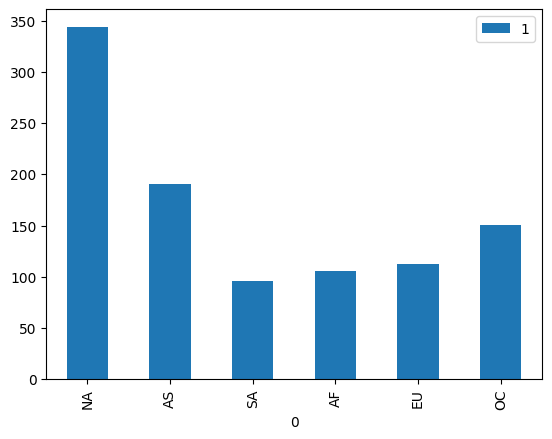

In [47]:
# Use a DF and render a plot

def get_people():
  query = "SELECT continent, COUNT(continent) FROM MOCK_DATA GROUP BY continent;"
  try:
    cur.execute(query)
    results = cur.fetchall()
    output = []
    for r in results:
      output.append(r)
    df = pd.DataFrame(output)
    df.plot.bar(x=0, y=1)
    return(df)
  except mysql.connector.Error as e:
    print("MySQL Error: ", str(e))

  cur.close()

get_people()